# Late Fusion by Ambiguity Groups - With EEG

This notebook splits trials into ambiguity groups (Low/Medium/High) and runs late fusion separately for each group, **including EEG as a fourth modality**.

**Note**: 
- EEG data is available for **85 subjects** (82 overlap with extracted features)
- This notebook uses `TIMEFRAME = 'PRE'`

In [1]:
# ============================================================================
# CONFIGURATION
# ============================================================================
TIMEFRAME = 'PRE'  # Fixed to PRE for merging with extracted_features_PRE

# EEG feature strategy - choose which level of features to use:
#   'channels_raw'   - 20 features: total power per electrode (base)
#   'regional_raw'   - 4 features: regional averages of total power
#   'channels_bands' - 80 features: 20 channels × 4 frequency bands
#   'regional_bands' - 16 features: 4 regions × 4 frequency bands (default)
#   'extended'       - 160 features: channels_bands + lateralization + temporal
EEG_STRATEGY = 'regional_bands'
# ============================================================================

import sys
sys.path.append('../..')  # Add project root to path

import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, f1_score
from sklearn.impute import SimpleImputer
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Import from src package
from src.utils.io import load_features, save_results
from src.utils.validation import validate_features
from src.models.fusion import weighted_late_fusion
from src.visualization.plots import set_style

np.random.seed(42)
set_style('whitegrid')

print(f"\n{'='*70}")
print(f"AMBIGUITY GROUP ANALYSIS WITH EEG: {TIMEFRAME}-DECISION PERIOD")
print(f"EEG Strategy: {EEG_STRATEGY}")
print(f"{'='*70}\n")


AMBIGUITY GROUP ANALYSIS WITH EEG: PRE-DECISION PERIOD
EEG Strategy: regional_bands



## 1. Load Pre-Extracted Features

In [2]:
# Load pre-extracted features using src utilities
features_path = f'../../data/features/extracted_features_{TIMEFRAME}.pkl'
feature_data = load_features(features_path, timeframe=TIMEFRAME)

merged_df = feature_data['merged_df']
physio_cols = feature_data['physio_cols']
behavior_cols = feature_data['behavior_cols']
gaze_cols = feature_data['gaze_cols']

# Validate loaded features
validate_features(merged_df, timeframe=TIMEFRAME)

print(f"\nAmbiguity distribution (all subjects):")
print(merged_df['ambiguity'].value_counts().sort_index())

✓ Validation passed (PRE): 12107 trials, 102 subjects
  Trials per subject: min=9, max=132, mean=118.7
  Outcome balance: 4197 keep / 7910 invest

Ambiguity distribution (all subjects):
ambiguity
0    4040
3    4035
6    4032
Name: count, dtype: int64


## 2. Load Pre-Extracted EEG Features

In [3]:
# Load pre-extracted EEG features based on selected strategy
# These pkl files are generated by 01_eeg_feature_extraction.ipynb

eeg_feature_file = f'../../data/features/eeg_features_{EEG_STRATEGY}.pkl'
print(f"Loading pre-extracted EEG features from: {eeg_feature_file}")

with open(eeg_feature_file, 'rb') as f:
    eeg_data = pickle.load(f)

eeg_features_df = eeg_data['eeg_features_df']
eeg_cols = eeg_data['feature_columns']

print(f"Loaded {len(eeg_features_df)} EEG trials from {eeg_features_df['subject_id'].nunique()} subjects")
print(f"EEG features ({len(eeg_cols)}): {eeg_cols[:5]}..." if len(eeg_cols) > 5 else f"EEG features ({len(eeg_cols)}): {eeg_cols}")
print(f"\nMetadata: {eeg_data['metadata']}")

Loading pre-extracted EEG features from: ../../data/features/eeg_features_regional_bands.pkl
Loaded 10212 EEG trials from 80 subjects
EEG features (16): ['eeg_Delta_Frontal', 'eeg_Delta_Central', 'eeg_Delta_Parietal', 'eeg_Delta_Occipital', 'eeg_Theta_Frontal']...

Metadata: {'strategy': 'regional_bands', 'level': 3, 'builds_on': 'channels_bands', 'sampling_rate': 256, 'frequency_bands': {'Delta': (0.5, 4), 'Theta': (4, 8), 'Alpha': (8, 13), 'Beta': (13, 30)}, 'regions': ['Frontal', 'Central', 'Parietal', 'Occipital'], 'channels': ['Fp1', 'F7', 'F8', 'T4', 'T6', 'T5', 'T3', 'Fp2', 'O1', 'P3', 'Pz', 'F3', 'Fz', 'F4', 'C4', 'P4', 'POz', 'C3', 'Cz', 'O2'], 'n_channels': 20, 'n_regions': 4, 'n_features': 16, 'feature_types': ['regional_band_power'], 'extraction_date': '2026-04-17 10:00:58', 'n_trials': 10212, 'n_subjects': 80, 'input_file': PosixPath('/Users/pranmodu/Projects/columbia/liinc_eye/data/eeg/display_window_2s.pkl'), 'description': 'EEG features extracted using regional_bands st

## 3. Merge Features and Filter to EEG Subjects

In [4]:
# Get EEG subjects
eeg_subjects = eeg_features_df['subject_id'].unique()
print(f"EEG subjects ({len(eeg_subjects)}): {eeg_subjects}")

# Filter merged_df to only EEG subjects
merged_df_eeg = merged_df[merged_df['subject_id'].isin(eeg_subjects)].copy()
print(f"\nFiltered to EEG subjects: {len(merged_df_eeg)} trials")

# Merge with EEG features on trial_id
merged_df_eeg = merged_df_eeg.merge(
    eeg_features_df[['trial_id'] + eeg_cols],
    on='trial_id',
    how='inner'
)

print(f"After merging with EEG: {len(merged_df_eeg)} trials")
print(f"Subjects: {merged_df_eeg['subject_id'].nunique()}")

# Check outcome balance
outcome_counts = merged_df_eeg['outcome'].value_counts()
print(f"\nOutcome balance: {outcome_counts.get(0, 0)} keep / {outcome_counts.get(1, 0)} invest")

EEG subjects (80): <StringArray>
['0731_1000_U9TEJGM', '0802_1400_U9TEJGM', '0811_1000_4LI8GO7',
 '0811_1000_U9TEJGM', '0813_1000_9M4VCHG', '0813_1000_U9TEJGM',
 '0816_1400_539136F', '0816_1400_9M4VCHG', '0816_1400_U9TEJGM',
 '0817_1000_539136F', '0817_1000_9M4VCHG', '0817_1000_U9TEJGM',
 '0818_1600_539136F', '0818_1600_9M4VCHG', '0818_1600_U9TEJGM',
 '0819_1400_539136F', '0819_1400_9M4VCHG', '0823_1400_539136F',
 '0823_1400_9M4VCHG', '0823_1400_U9TEJGM', '0824_1000_539136F',
 '0824_1000_9M4VCHG', '0824_1000_U9TEJGM', '0824_1600_539136F',
 '0824_1600_9M4VCHG', '0826_1000_539136F', '0826_1000_9M4VCHG',
 '0826_1300_539136F', '0826_1300_9M4VCHG', '0826_1300_U9TEJGM',
 '0827_1000_539136F', '0827_1000_9M4VCHG', '0827_1000_U9TEJGM',
 '0828_1300_9M4VCHG', '0828_1300_U9TEJGM', '0830_1300_539136F',
 '0830_1300_9M4VCHG', '0830_1300_U9TEJGM', '0831_1300_539136F',
 '0831_1300_9M4VCHG', '0831_1300_U9TEJGM', '0901_1000_539136F',
 '0901_1000_9M4VCHG', '0901_1000_U9TEJGM', '0901_1300_539136F',
 '0901_

## 4. Create Ambiguity Groups

In [5]:
# Create ambiguity groups
merged_df_eeg['ambiguity_group'] = merged_df_eeg['ambiguity'].replace({0:'Low', 3:'Medium', 6:'High'})

print("\nAmbiguity group distribution (EEG subjects only):")
print(merged_df_eeg['ambiguity_group'].value_counts())

print(f"\nFeature counts:")
print(f"  Physiology ({TIMEFRAME}): {len(physio_cols)} features")
print(f"  Behavior: {len(behavior_cols)} features")
print(f"  Gaze: {len(gaze_cols)} features")
print(f"  EEG: {len(eeg_cols)} features")


Ambiguity group distribution (EEG subjects only):
ambiguity_group
Low       3143
Medium    3121
High      3101
Name: count, dtype: int64

Feature counts:
  Physiology (PRE): 13 features
  Behavior: 11 features
  Gaze: 20 features
  EEG: 16 features


## 5. Run Late Fusion for Each Ambiguity Group

In [6]:
# Run late fusion for each ambiguity group
group_results = {}

for group in ['Low', 'Medium', 'High']:
    print(f"\n{'='*80}")
    print(f"Analyzing {group} Ambiguity Group (with EEG)")
    print(f"{'='*80}")
    
    # Filter data for this group
    group_df = merged_df_eeg[merged_df_eeg['ambiguity_group'] == group].copy()
    
    # Check if we have enough subjects
    n_subjects = group_df['subject_id'].nunique()
    if n_subjects < 3:
        print(f"  Skipping - only {n_subjects} subjects in this group")
        continue
    
    # Prepare feature matrices
    imputer = SimpleImputer(strategy='mean')
    X_physio = imputer.fit_transform(group_df[physio_cols])
    X_behavior = imputer.fit_transform(group_df[behavior_cols])
    X_gaze = imputer.fit_transform(group_df[gaze_cols]) if len(gaze_cols) > 0 else np.zeros((len(group_df), 1))
    X_eeg = imputer.fit_transform(group_df[eeg_cols])
    
    y = group_df['outcome'].values
    subjects = group_df['subject_id'].values
    
    # Setup modalities (include EEG)
    if len(gaze_cols) > 0:
        X_modalities = [X_physio, X_behavior, X_gaze, X_eeg]
        modality_names = ['Physiology', 'Behavior', 'Gaze', 'EEG']
    else:
        X_modalities = [X_physio, X_behavior, X_eeg]
        modality_names = ['Physiology', 'Behavior', 'EEG']
    
    print(f"\nRunning weighted late fusion for {group} group...")
    print(f"  N trials: {len(y)}")
    print(f"  N subjects: {n_subjects}")
    print(f"  Outcome: {(y==0).sum()} keep / {(y==1).sum()} invest")
    
    # Run fusion
    results = weighted_late_fusion(X_modalities, y, subjects, modality_names)
    results['modality_names'] = modality_names
    group_results[group] = results
    
    print(f"\nResults for {group} group:")
    print(f"  Accuracy: {results['accuracy_mean']:.3f} +/- {results['accuracy_sem']:.3f} (SEM)")
    print(f"  F1-Score: {results['f1_mean']:.3f} +/- {results['f1_sem']:.3f} (SEM)")
    print(f"  Weights:")
    for name, w in zip(modality_names, results['weights']):
        print(f"    {name}: {w*100:.1f}%")


Analyzing Low Ambiguity Group (with EEG)

Running weighted late fusion for Low group...
  N trials: 3143
  N subjects: 80
  Outcome: 578 keep / 2565 invest


/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.w


Results for Low group:
  Accuracy: 0.813 +/- 0.021 (SEM)
  F1-Score: 0.751 +/- 0.026 (SEM)
  Weights:
    Physiology: 0.6%
    Behavior: 60.5%
    Gaze: 38.4%
    EEG: 0.5%

Analyzing Medium Ambiguity Group (with EEG)

Running weighted late fusion for Medium group...
  N trials: 3121
  N subjects: 80
  Outcome: 990 keep / 2131 invest


/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.w


Results for Medium group:
  Accuracy: 0.737 +/- 0.021 (SEM)
  F1-Score: 0.708 +/- 0.021 (SEM)
  Weights:
    Physiology: 0.5%
    Behavior: 85.7%
    Gaze: 13.4%
    EEG: 0.3%

Analyzing High Ambiguity Group (with EEG)

Running weighted late fusion for High group...
  N trials: 3101
  N subjects: 80
  Outcome: 1640 keep / 1461 invest

Results for High group:
  Accuracy: 0.707 +/- 0.018 (SEM)
  F1-Score: 0.682 +/- 0.019 (SEM)
  Weights:
    Physiology: 3.0%
    Behavior: 64.3%
    Gaze: 32.1%
    EEG: 0.6%


## 6. Compare Results Across Groups

In [ ]:
# Build comparison dataframe
comparison_rows = []
for group, results in group_results.items():
    modality_names = results.get('modality_names', ['Physiology', 'Behavior', 'Gaze', 'EEG'])
    row = {
        'Group': group,
        'N_Trials': results['n_trials'],
        'N_Subjects': results['n_subjects'],
        'Accuracy': results['accuracy_mean'],
        'Accuracy_SEM': results['accuracy_sem'],
        'Accuracy_SD': results['accuracy_std'],
        'F1-Score': results['f1_mean'],
        'F1_SEM': results['f1_sem'],
    }
    # Add weights for each modality
    for i, name in enumerate(modality_names):
        row[f'{name}_Weight'] = results['weights'][i] if i < len(results['weights']) else 0
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)

print("\n" + "="*80)
print(f"COMPARISON ACROSS AMBIGUITY GROUPS - WITH EEG (N={merged_df_eeg['subject_id'].nunique()} subjects)")
print("="*80)
print(comparison_df[['Group', 'N_Trials', 'N_Subjects', 'Accuracy', 'Accuracy_SEM', 'F1-Score']].to_string(index=False))


COMPARISON ACROSS AMBIGUITY GROUPS - WITH EEG (N=80 subjects)
 Group  N_Trials  N_Subjects  Accuracy  Accuracy_SEM  F1-Score
   Low      3143          80  0.812765      0.021266  0.750604
Medium      3121          80  0.736764      0.020706  0.707954
  High      3101          80  0.706997      0.017848  0.682027

NOTE: This analysis uses only 10 subjects (those with EEG data)
ERROR BARS: SEM (Standard Error of Mean) from subject-level accuracies


## 7. Visualizations

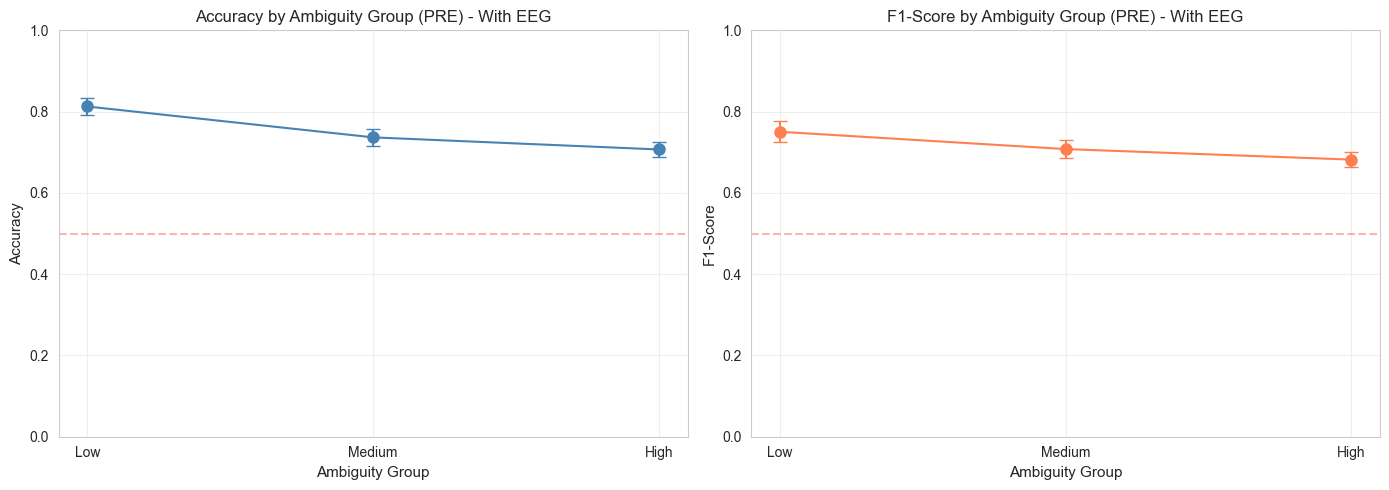

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy with SEM error bars
ax = axes[0]
ax.errorbar(comparison_df['Group'], comparison_df['Accuracy'], 
            yerr=comparison_df['Accuracy_SEM'], fmt='o-', capsize=5, color='steelblue', markersize=8)
ax.set_xlabel('Ambiguity Group')
ax.set_ylabel('Accuracy')
ax.set_title(f'Accuracy by Ambiguity Group ({TIMEFRAME}) - With EEG')
ax.set_ylim([0, 1])
ax.axhline(0.5, color='red', linestyle='--', alpha=0.3, label='Chance')
ax.grid(alpha=0.3)

# F1-Score with SEM error bars
ax = axes[1]
ax.errorbar(comparison_df['Group'], comparison_df['F1-Score'], 
            yerr=comparison_df['F1_SEM'], fmt='o-', capsize=5, color='coral', markersize=8)
ax.set_xlabel('Ambiguity Group')
ax.set_ylabel('F1-Score')
ax.set_title(f'F1-Score by Ambiguity Group ({TIMEFRAME}) - With EEG')
ax.set_ylim([0, 1])
ax.axhline(0.5, color='red', linestyle='--', alpha=0.3)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

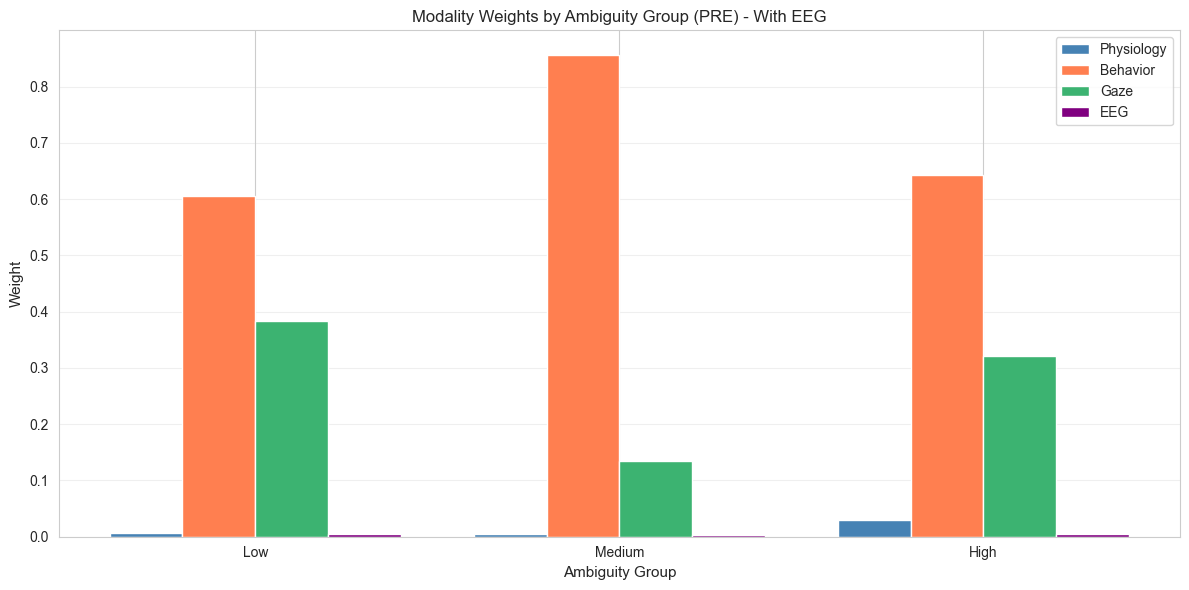

In [9]:
# Modality weights by group (including EEG)
fig, ax = plt.subplots(figsize=(12, 6))

# Get modality columns
weight_cols = [c for c in comparison_df.columns if c.endswith('_Weight')]
modality_names_plot = [c.replace('_Weight', '') for c in weight_cols]

x = np.arange(len(comparison_df))
width = 0.2
colors = ['steelblue', 'coral', 'mediumseagreen', 'purple']

for i, (col, name) in enumerate(zip(weight_cols, modality_names_plot)):
    offset = (i - len(weight_cols)/2 + 0.5) * width
    ax.bar(x + offset, comparison_df[col], width, label=name, color=colors[i % len(colors)])

ax.set_xlabel('Ambiguity Group')
ax.set_ylabel('Weight')
ax.set_title(f'Modality Weights by Ambiguity Group ({TIMEFRAME}) - With EEG')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Group'])
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 8. Subject-Level Accuracy Distributions

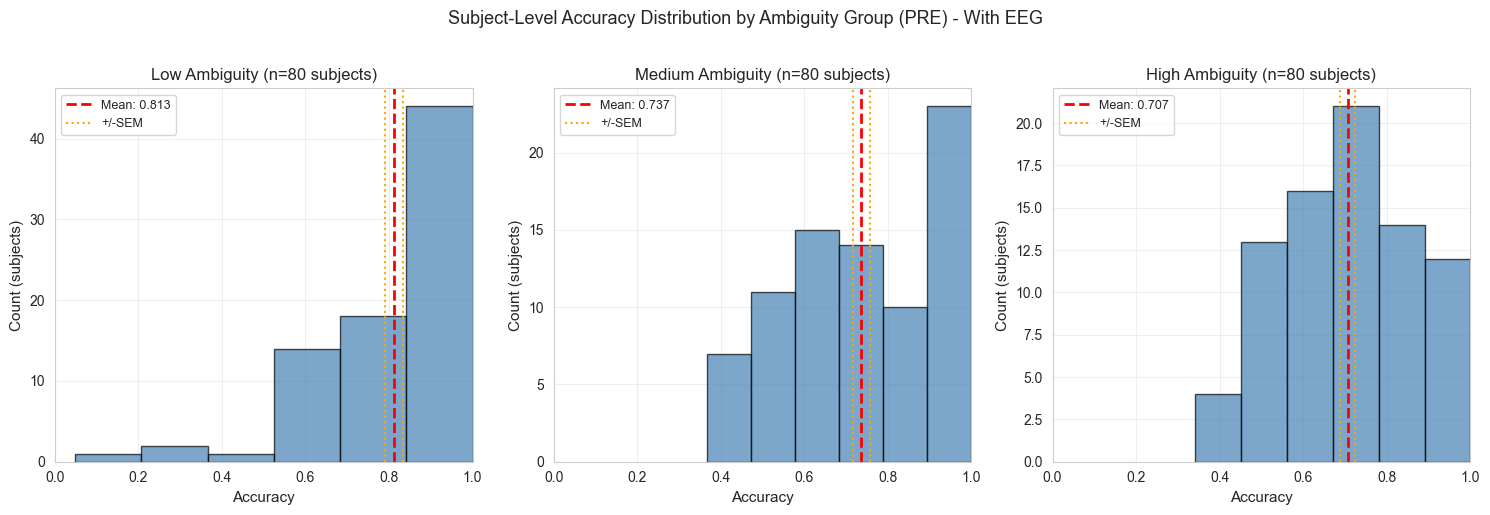

In [10]:
# Plot subject-level accuracy distributions for each ambiguity group
n_groups = len(group_results)
fig, axes = plt.subplots(1, n_groups, figsize=(5*n_groups, 5))
if n_groups == 1:
    axes = [axes]

for idx, (group, results) in enumerate(group_results.items()):
    ax = axes[idx]
    subject_accs = results['accuracy_per_subject']
    
    # Histogram
    ax.hist(subject_accs, bins=6, color='steelblue', alpha=0.7, edgecolor='black')
    ax.axvline(results['accuracy_mean'], color='red', linestyle='--', linewidth=2,
               label=f"Mean: {results['accuracy_mean']:.3f}")
    ax.axvline(results['accuracy_mean'] - results['accuracy_sem'], color='orange',
               linestyle=':', linewidth=1.5, label=f"+/-SEM")
    ax.axvline(results['accuracy_mean'] + results['accuracy_sem'], color='orange',
               linestyle=':', linewidth=1.5)
    
    ax.set_xlabel('Accuracy')
    ax.set_ylabel('Count (subjects)')
    ax.set_title(f'{group} Ambiguity (n={results["n_subjects"]} subjects)')
    ax.set_xlim([0, 1])
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle(f'Subject-Level Accuracy Distribution by Ambiguity Group ({TIMEFRAME}) - With EEG', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 9. Save Results

In [11]:
import os
output_dir = f'../../data/results/main/eeg_integration/fusion_models_eeg_{TIMEFRAME}'
os.makedirs(output_dir, exist_ok=True)

# Save comparison results across groups
save_results(comparison_df, f'{output_dir}/ambiguity_group_eeg_{TIMEFRAME}_comparison.csv')

# Save detailed group results
for group_name, results in group_results.items():
    modality_names = results.get('modality_names', ['Physiology', 'Behavior', 'Gaze', 'EEG'])
    
    # Save modality weights
    weights_df = pd.DataFrame({
        'Modality': modality_names[:len(results['weights'])],
        'Weight': results['weights']
    })
    save_results(weights_df, f'{output_dir}/ambiguity_group_eeg_{TIMEFRAME}_{group_name}_weights.csv')

    # Save subject-level accuracies
    if 'accuracy_per_subject' in results:
        subject_df = pd.DataFrame({
            'accuracy': results['accuracy_per_subject'],
            'f1_score': results.get('f1_per_subject', [])
        })
        save_results(subject_df, f'{output_dir}/ambiguity_group_eeg_{TIMEFRAME}_{group_name}_subject_accuracies.csv')

print(f"\nAll results saved to: {output_dir}/")

✓ Saved results to: ../../data/results/main/eeg_integration/fusion_models_eeg_PRE/ambiguity_group_eeg_PRE_comparison.csv
✓ Saved results to: ../../data/results/main/eeg_integration/fusion_models_eeg_PRE/ambiguity_group_eeg_PRE_Low_weights.csv
✓ Saved results to: ../../data/results/main/eeg_integration/fusion_models_eeg_PRE/ambiguity_group_eeg_PRE_Low_subject_accuracies.csv
✓ Saved results to: ../../data/results/main/eeg_integration/fusion_models_eeg_PRE/ambiguity_group_eeg_PRE_Medium_weights.csv
✓ Saved results to: ../../data/results/main/eeg_integration/fusion_models_eeg_PRE/ambiguity_group_eeg_PRE_Medium_subject_accuracies.csv
✓ Saved results to: ../../data/results/main/eeg_integration/fusion_models_eeg_PRE/ambiguity_group_eeg_PRE_High_weights.csv
✓ Saved results to: ../../data/results/main/eeg_integration/fusion_models_eeg_PRE/ambiguity_group_eeg_PRE_High_subject_accuracies.csv

All results saved to: ../../data/results/main/eeg_integration/fusion_models_eeg_PRE/
